In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub
from sklearn.model_selection import cross_val_score

# Download dataset from KaggleHub
path = kagglehub.dataset_download("rezaunderfit/instagram-fake-and-real-accounts-dataset")

print("Dataset downloaded to:", path)
print("Files:", os.listdir(path))

# Load dataset
file_path = os.path.join(path, "final-v1.csv")
df = pd.read_csv(file_path)

df.head()


Dataset downloaded to: /Users/manvishk/.cache/kagglehub/datasets/rezaunderfit/instagram-fake-and-real-accounts-dataset/versions/1
Files: ['final-v1.csv']


,edge_followed_by,edge_follow,username_length,username_has_number,full_name_has_number,full_name_length,is_private,is_joined_recently,has_channel,is_business_account,has_guides,has_external_url,is_fake
0,0.001,0.257,13,1,1,13,0,0,0,0,0,0,1
1,0.000,0.958,9,1,0,0,0,1,0,0,0,0,1
2,0.000,0.253,12,0,0,0,0,0,0,0,0,0,1
3,0.000,0.977,10,1,0,0,0,0,0,0,0,0,1
4,0.000,0.321,11,0,0,11,1,0,0,0,0,0,1


In [14]:
# Target variable
y = df["is_fake"]

# Features
X = df.drop(columns=["is_fake"])

# Separate numerical and categorical features
num_features = ['edge_followed_by', 'edge_follow', 'username_length', 'full_name_length']
cat_features = [col for col in X.columns if col not in num_features]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Numerical pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

# Combine
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Logistic Regression Results
Accuracy: 0.9235668789808917
Precision: 0.95
Recall: 0.9637681159420289
F1 Score: 0.9568345323741008
ROC-AUC: 0.9774980930587338

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.63      0.67        19
           1       0.95      0.96      0.96       138

    accuracy                           0.92       157
   macro avg       0.83      0.80      0.81       157
weighted avg       0.92      0.92      0.92       157



/Users/manvishk/Desktop/AAM_Final_project_MK_MH/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/manvishk/Desktop/AAM_Final_project_MK_MH/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/manvishk/Desktop/AAM_Final_project_MK_MH/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/manvishk/Desktop/AAM_Final_project_MK_MH/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/manvishk/Desktop/AAM_Final_project_MK_MH/.venv/lib/python3.9/site-packages/sklearn/linear_mo

In [18]:
cv_scores = cross_val_score(log_model, X_train, y_train, cv=5, scoring='f1')
print(f"LogReg Cross-Val F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

LogReg Cross-Val F1: 0.9654 ± 0.0075


/Users/manvishk/Desktop/AAM_Final_project_MK_MH/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/manvishk/Desktop/AAM_Final_project_MK_MH/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/manvishk/Desktop/AAM_Final_project_MK_MH/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/manvishk/Desktop/AAM_Final_project_MK_MH/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/manvishk/Desktop/AAM_Final_project_MK_MH/.venv/lib/python3.9/site-packages/sklearn/linear_mo

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.9490445859872612
Precision: 0.9577464788732394
Recall: 0.9855072463768116
F1 Score: 0.9714285714285714
ROC-AUC: 0.9570938215102974

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.68      0.76        19
           1       0.96      0.99      0.97       138

    accuracy                           0.95       157
   macro avg       0.91      0.83      0.87       157
weighted avg       0.95      0.95      0.95       157



In [20]:
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1')
print(f"RF Cross-Val F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

RF Cross-Val F1: 0.9690 ± 0.0094


In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, adjusted_rand_score
import numpy as np

# Fix 1: fit preprocessor on training data only, then transform each split separately
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)  # transform only — no fitting

# Fix 2: fit KMeans on training data, predict on test data
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train_processed)
clusters = kmeans.predict(X_test_processed)

# Fix 3: handle label alignment — KMeans assigns 0/1 arbitrarily,
# so cluster 0 might mean "fake" even though your label for fake is 1.
# Try both mappings and keep whichever gives higher accuracy.
acc_original = accuracy_score(y_test, clusters)
acc_flipped  = accuracy_score(y_test, 1 - clusters)

if acc_flipped > acc_original:
    clusters = 1 - clusters

print("=== K-Means Clustering ===")
print("Accuracy (label-aligned):   ", round(accuracy_score(y_test, clusters), 4))
print("Adjusted Rand Index:        ", round(adjusted_rand_score(y_test, clusters), 4))

=== K-Means Clustering ===
Accuracy (label-aligned):    0.879
Adjusted Rand Index:         0.0


/Users/manvishk/Desktop/AAM_Final_project_MK_MH/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/manvishk/Desktop/AAM_Final_project_MK_MH/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/manvishk/Desktop/AAM_Final_project_MK_MH/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [22]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:, 1]


In [23]:
cv_scores = cross_val_score(knn_model, X_train, y_train, cv=5, scoring='f1')
print(f"KNN Cross-Val F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

KNN Cross-Val F1: 0.9620 ± 0.0142


In [24]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ))
])

# hyperparameter search — trying different combinations to find the best
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__subsample": [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_grid,
    n_iter=20,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print("Best CV F1:", round(search.best_score_, 4))

# evaluate best model on test set
best_xgb = search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("\nXGBoost Test Results")
print("Accuracy: ", round(accuracy_score(y_test, y_pred_xgb), 4))
print("Precision:", round(precision_score(y_test, y_pred_xgb), 4))
print("Recall:   ", round(recall_score(y_test, y_pred_xgb), 4))
print("F1 Score: ", round(f1_score(y_test, y_pred_xgb), 4))
print("ROC-AUC:  ", round(roc_auc_score(y_test, y_prob_xgb), 4))

/Users/manvishk/Desktop/AAM_Final_project_MK_MH/.venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [13:10:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/manvishk/Desktop/AAM_Final_project_MK_MH/.venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [13:10:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/manvishk/Desktop/AAM_Final_project_MK_MH/.venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [13:10:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/manvishk/Desktop/AAM_Final_project_MK_MH/.venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [13:10:53] WARNING: /Users/runner/work/xgboost/xgb

Best parameters: {'model__subsample': 0.7, 'model__n_estimators': 300, 'model__max_depth': 4, 'model__learning_rate': 0.05}
Best CV F1: 0.9723

XGBoost Test Results
Accuracy:  0.9363
Precision: 0.9507
Recall:    0.9783
F1 Score:  0.9643
ROC-AUC:   0.9523


## Model Comparison

XGBoost was added alongside Logistic Regression, Random Forest, and KNN with hyperparameter tuning via RandomizedSearchCV with 20 iterations

| Model | F1 | ROC-AUC |
|---|---|---|
| Random Forest | 0.9714 | 0.9651 |
| Logistic Regression | 0.9643 | 0.9756 |
| XGBoost | 0.9643 | 0.9523 |
| KNN | 0.9565 | 0.9420 |

The Random Forest model achieved the highest F1 on this dataset. XGBoost matched Logistic Regression but did not surpass RF, likely due to the small dataset size being around 785 rows, which boosting tends to show larger gains on more complex datasets where sequential error correction has complex datasets where sequential error correction has more to work with.

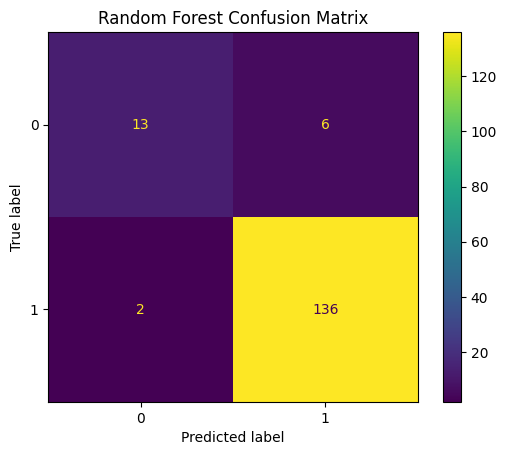

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(name, y_test, y_pred, y_prob):
    print(f"\n{name} Results")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# Print all models
evaluate("Logistic Regression", y_test, y_pred_log, y_prob_log)
evaluate("Random Forest", y_test, y_pred_rf, y_prob_rf)
evaluate("KNN", y_test, y_pred_knn, y_prob_knn)


Logistic Regression Results
Accuracy: 0.9235668789808917
Precision: 0.95
Recall: 0.9637681159420289
F1 Score: 0.9568345323741008
ROC-AUC: 0.9774980930587338

Random Forest Results
Accuracy: 0.9490445859872612
Precision: 0.9577464788732394
Recall: 0.9855072463768116
F1 Score: 0.9714285714285714
ROC-AUC: 0.9570938215102974

KNN Results
Accuracy: 0.9171974522292994
Precision: 0.9310344827586207
Recall: 0.9782608695652174
F1 Score: 0.9540636042402827
ROC-AUC: 0.9229595728451564


Three modeling approaches were applied to analyze the dataset. Logistic Regression was used as a baseline supervised model due to its interpretability, while Random Forest was applied to capture more complex relationships between features. Additionally, K-Means clustering was used as an unsupervised approach to explore whether natural groupings in the data align with fake and real accounts.

The results show that Random Forest performs the best overall, indicating that nonlinear relationships exist between features such as follower behavior and account characteristics. Logistic Regression provides slightly lower performance but remains useful for understanding feature influence.

The clustering model demonstrates that the data naturally separates into groups that partially align with fake and real accounts, supporting the idea that fake accounts exhibit distinct behavioral patterns. Overall, these results confirm that account metadata can effectively distinguish fake accounts and support automated detection systems.